In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#Read Dataset
df = pd.read_excel("World-Happiness-26.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   object 
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by

In [ ]:
# There is no valid data befor 2019. so we need to get after 2019
df_2019 = df[df['Year'] >= 2019]

#Making column names easier :)
df_2019 = df_2019.rename(columns={
    'Country name': 'Country',
    'Life evaluation (3-year average)': 'Happiness',
    'Explained by: Log GDP per capita': 'Log GDP per capita',
    'Explained by: Social support': 'Social support',
    'Explained by: Healthy life expectancy': 'Healthy life expectancy',
    'Explained by: Freedom to make life choices': 'Freedom to make life choices',
    'Explained by: Generosity': 'Generosity',
    'Explained by: Perceptions of corruption': 'Perceptions of corruption'
})

df_2019.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1022 entries, 0 to 1021
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          1022 non-null   int64  
 1   Rank                          1022 non-null   int64  
 2   Country                       1022 non-null   object 
 3   Happiness                     1022 non-null   float64
 4   Lower whisker                 1022 non-null   float64
 5   Upper whisker                 1022 non-null   float64
 6   Log GDP per capita            1019 non-null   float64
 7   Social support                1019 non-null   float64
 8   Healthy life expectancy       1016 non-null   float64
 9   Freedom to make life choices  1017 non-null   float64
 10  Generosity                    1019 non-null   float64
 11  Perceptions of corruption     1018 non-null   float64
 12  Dystopia + residual           1013 non-null   float64
dtypes: float

In [ ]:
############################################
# I fill NaN Values with Mean of other Years
############################################

countries = df_2019['Country'].unique()
years = range(2019, 2026)

full_index = pd.MultiIndex.from_product([countries, years], names=['Country', 'Year'])
df_2019 = df_2019.set_index(['Country', 'Year']).reindex(full_index).reset_index()

num_cols = ['Rank', 'Happiness',
 'Lower whisker', 'Upper whisker', 'Log GDP per capita',
 'Social support', 'Healthy life expectancy',
 'Freedom to make life choices', 'Generosity',
 'Perceptions of corruption', 'Dystopia + residual']

df_2019[num_cols] = df_2019[num_cols].apply(
    lambda col: col.fillna(df_2019.groupby('Country')[col.name].transform('mean'))
)

df_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1099 entries, 0 to 1098
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       1099 non-null   object 
 1   Year                          1099 non-null   int64  
 2   Rank                          1099 non-null   float64
 3   Happiness                     1099 non-null   float64
 4   Lower whisker                 1099 non-null   float64
 5   Upper whisker                 1099 non-null   float64
 6   Log GDP per capita            1099 non-null   float64
 7   Social support                1099 non-null   float64
 8   Healthy life expectancy       1099 non-null   float64
 9   Freedom to make life choices  1099 non-null   float64
 10  Generosity                    1099 non-null   float64
 11  Perceptions of corruption     1099 non-null   float64
 12  Dystopia + residual           1099 non-null   float64
dtypes: 

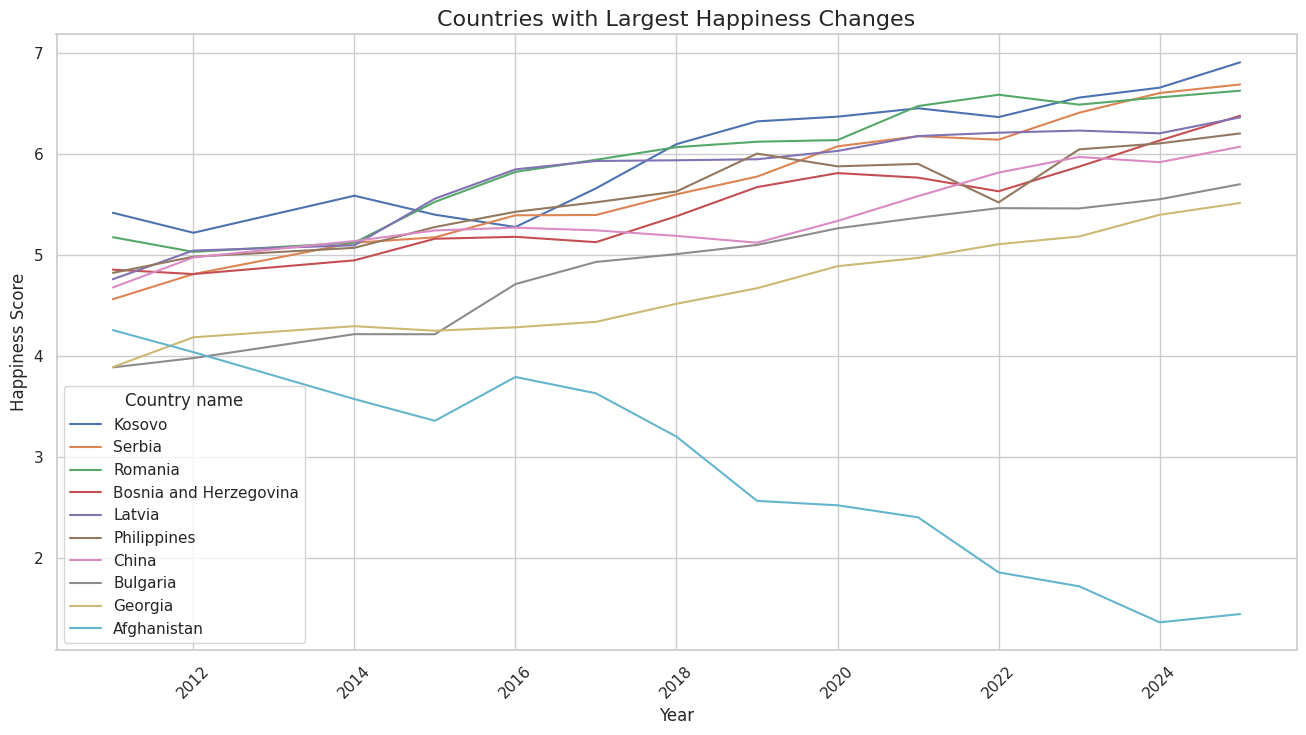

In [ ]:
###############################################################
####### 10 countries with the most changes in happiness #######
###############################################################

change = (
    df.sort_values(['Country name', 'Year'])
      .groupby('Country name')['Life evaluation (3-year average)']
      .agg(['first', 'last'])
)
change['difference'] = change['last'] - change['first']
change['abs_difference'] = change['difference'].abs()

top10changes = (change.sort_values('abs_difference', ascending=False)
              .head(10)
              .reset_index()['Country name'])

data = df[df['Country name'].isin(top10changes.values)]

plt.figure(figsize=(16,8))
sns.lineplot(
    data=data,
    x='Year',
    y='Life evaluation (3-year average)',
    hue='Country name'
)

plt.title('Countries with Largest Happiness Changes', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('Happiness Score', fontsize=12)
plt.show()





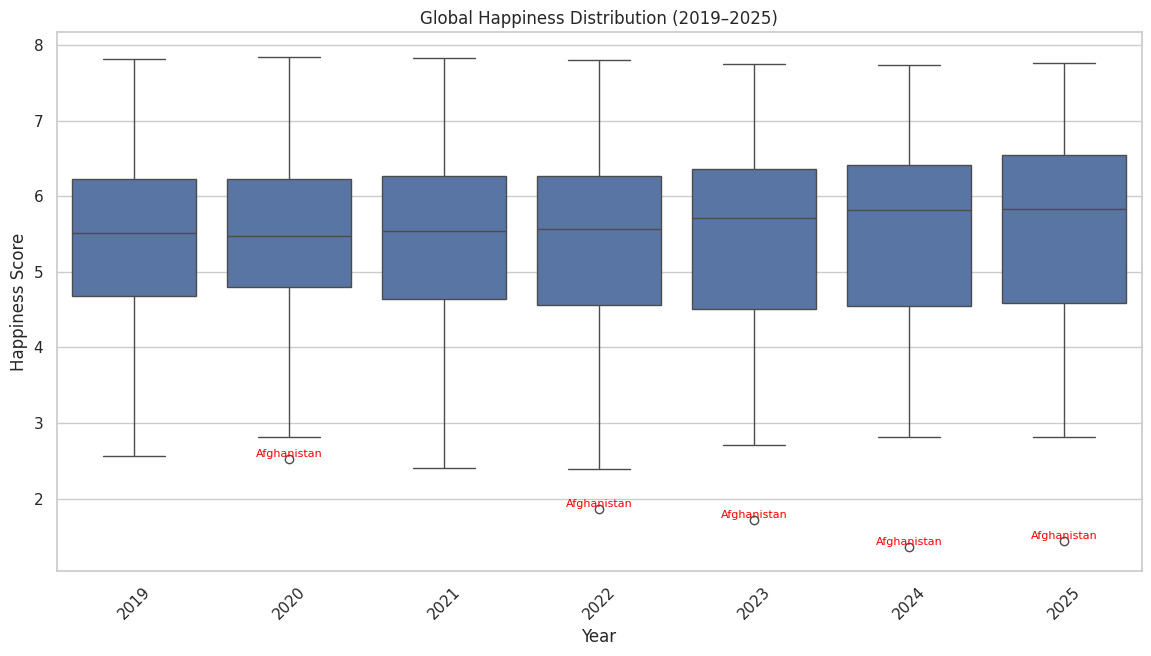

In [ ]:
#################################################################
####### Global Happiness Distribution by Year (2019–2025) #######
#################################################################


plt.figure(figsize=(14,7))

ax = sns.boxplot(
    data=df_2019,
    x='Year',
    y='Happiness',
    showfliers=True
)

# get outlier name
years = sorted(df_2019['Year'].unique())

for i, year in enumerate(years):
    data_year = df_2019[df_2019['Year'] == year]

    Q1 = data_year['Happiness'].quantile(0.25)
    Q3 = data_year['Happiness'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data_year[
        (data_year['Happiness'] < lower) |
        (data_year['Happiness'] > upper)
    ]

    for _, row in outliers.iterrows():
        plt.text(
            i,
            row['Happiness'],
            row['Country'],
            fontsize=8,
            color='red',
            ha='center',
            va='bottom'
        )

plt.xticks(rotation=45)
plt.title('Global Happiness Distribution (2019–2025)', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.show()

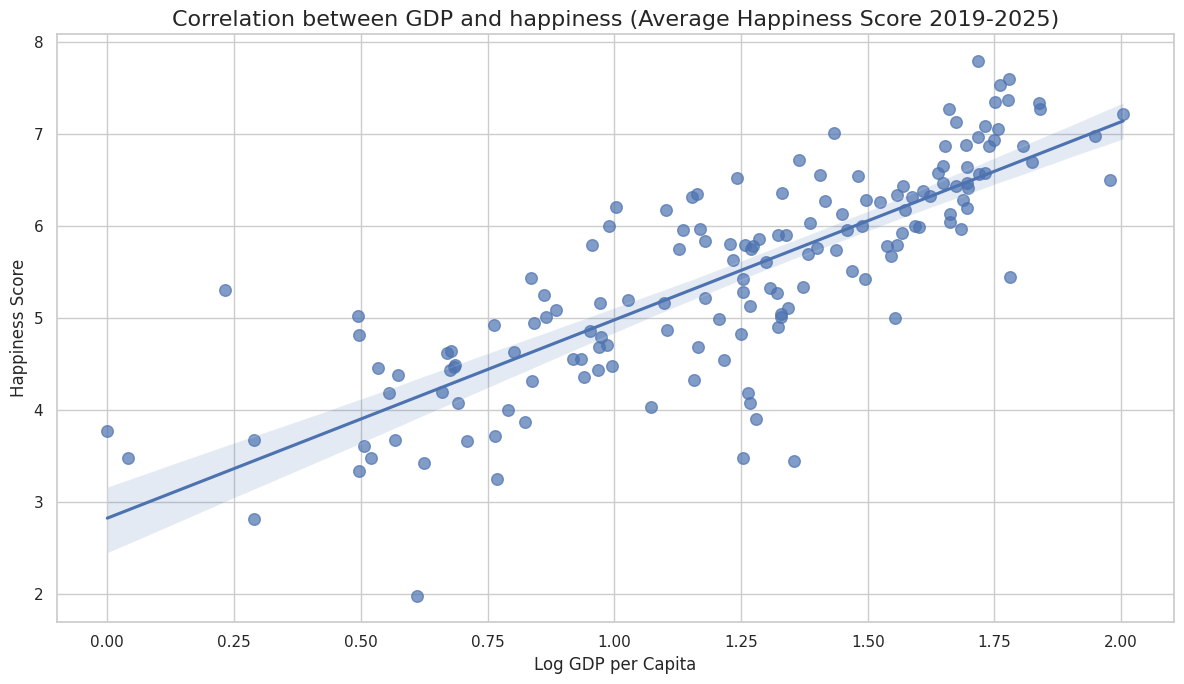

In [ ]:
#####################################################
####### Correlation between GDP and happiness #######
#####################################################

country_gdp_happiness_mean = (
    df_2019.groupby('Country')[['Happiness','Log GDP per capita']]
    .mean()
    )

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

sns.regplot(
    x='Log GDP per capita',
    y='Happiness',
    data=country_gdp_happiness_mean,
    scatter_kws={'s': 70, 'alpha': 0.7}
)

plt.title('Correlation between GDP and happiness (Average Happiness Score 2019-2025)', fontsize=16)
plt.xlabel('Log GDP per Capita', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)

plt.tight_layout()
plt.show()

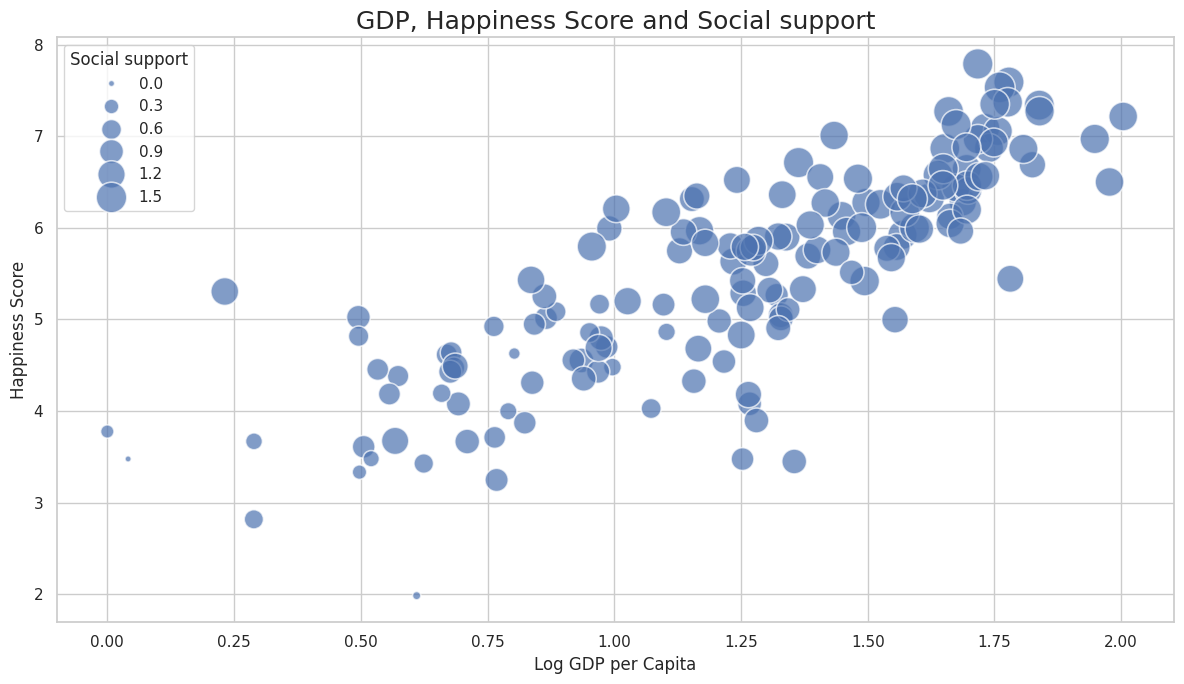

In [ ]:
#####################################################################
####### Correlation between GDP, happiness and Sucial support #######
#####################################################################

country_gdp_happiness_SocialSupport_mean = (
    df_2019.groupby('Country')[['Happiness','Log GDP per capita','Social support']]
    .mean()
    )

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=country_gdp_happiness_SocialSupport_mean,
    x='Log GDP per capita',
    y='Happiness',
    size='Social support',
    sizes=(20,500),
    alpha=0.7
)
plt.title('GDP, Happiness Score and Social support', fontsize=18)
plt.xlabel('Log GDP per Capita', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)

plt.tight_layout()
plt.show()

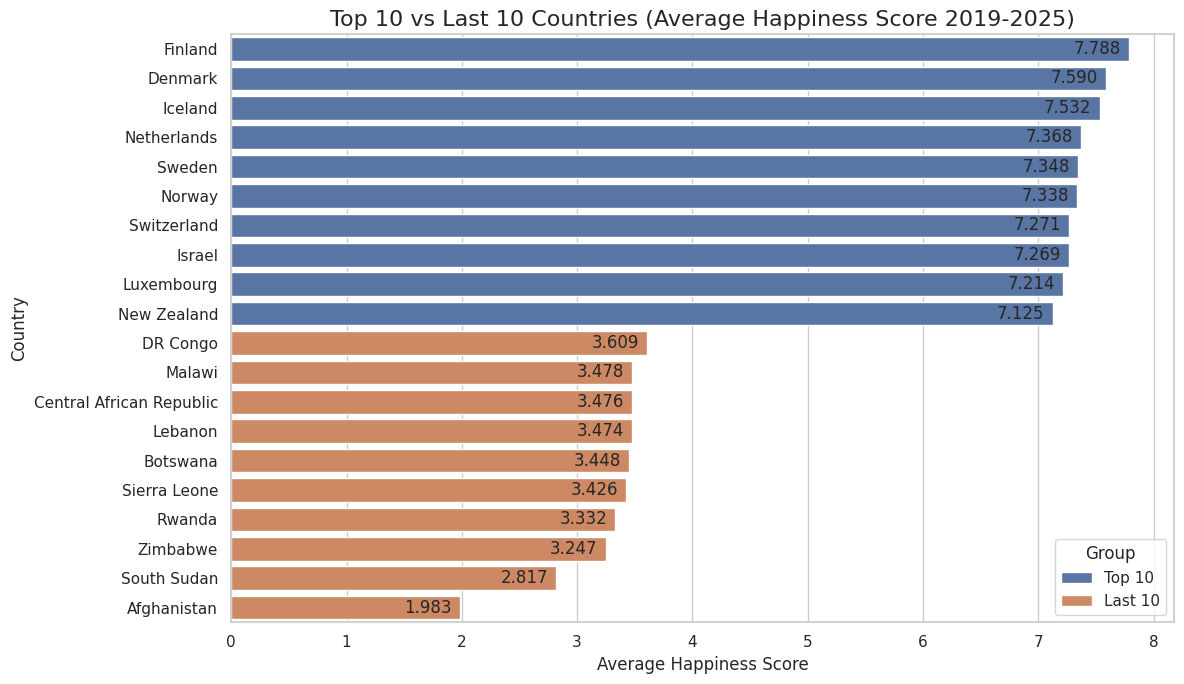

In [ ]:
######################################################################
####### Top 10 happiest countries vs Last 10happiest Countries #######
######################################################################

country_happiness_mean = (df_2019.groupby('Country')[['Happiness','Log GDP per capita']]
                .mean()
                .sort_values(by='Happiness', ascending=False))

top10 = country_happiness_mean.head(10)
last10 = country_happiness_mean.tail(10)

#combined for set different colors
combined = pd.concat([top10, last10]).reset_index()
combined.columns = ['Country', 'Happiness', 'Log GDP per capita']
combined['Group'] = ['Top 10']*10 + ['Last 10']*10

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=combined,
    x='Happiness',
    y='Country',
    hue='Group'
)

# add lables
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=-40)

plt.title('Top 10 vs Last 10 Countries (Average Happiness Score 2019-2025)', fontsize=16)
plt.xlabel('Average Happiness Score', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

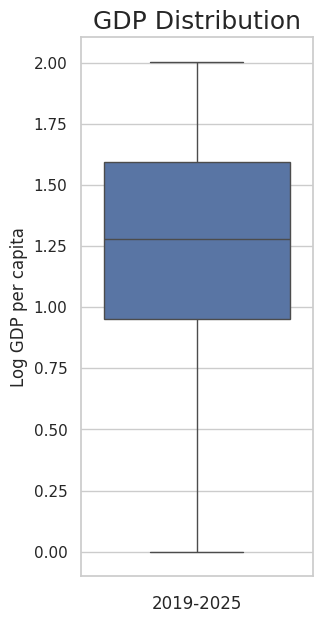

In [ ]:
#####################################################################
####### Avrage of Log GDP per capita Distribution (2019–2025) #######
#####################################################################

country_happiness_mean = (df_2019.groupby('Country')[['Happiness','Log GDP per capita']]
                .mean()
                .sort_values(by='Happiness', ascending=False))

plt.figure(figsize=(3,7))

ax = sns.boxplot(
    data=country_happiness_mean,
    y='Log GDP per capita',
    showfliers=True
)


plt.title('GDP Distribution', fontsize=18)
plt.ylabel('Log GDP per capita', fontsize=12)
plt.xlabel('2019-2025', fontsize=12)
plt.show()

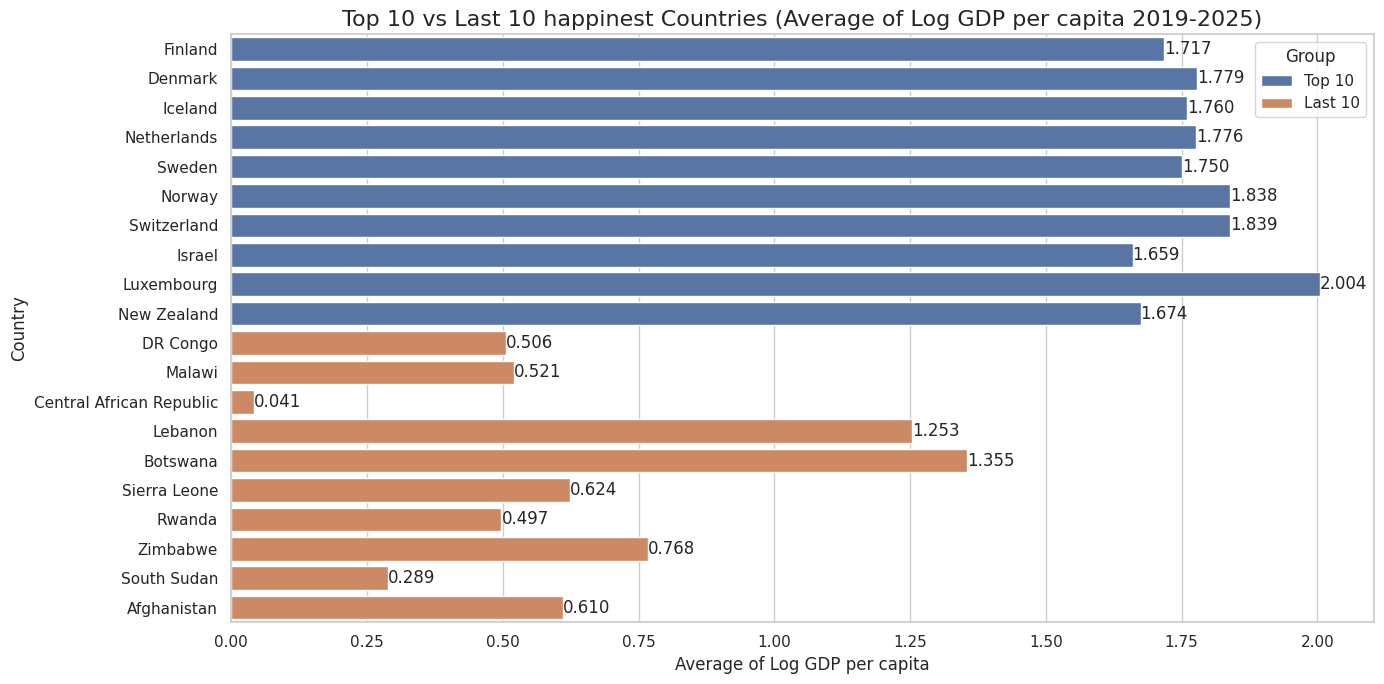

In [ ]:
##########################################################################
####### Top 10 countries vs Last 10 Countries (Log GDP per capita) #######
##########################################################################

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=combined,
    x='Log GDP per capita',
    y='Country',
    hue='Group'
)

# add lables
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=0)

plt.title('Top 10 vs Last 10 happinest Countries (Average of Log GDP per capita 2019-2025)', fontsize=16)
plt.xlabel('Average of Log GDP per capita', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

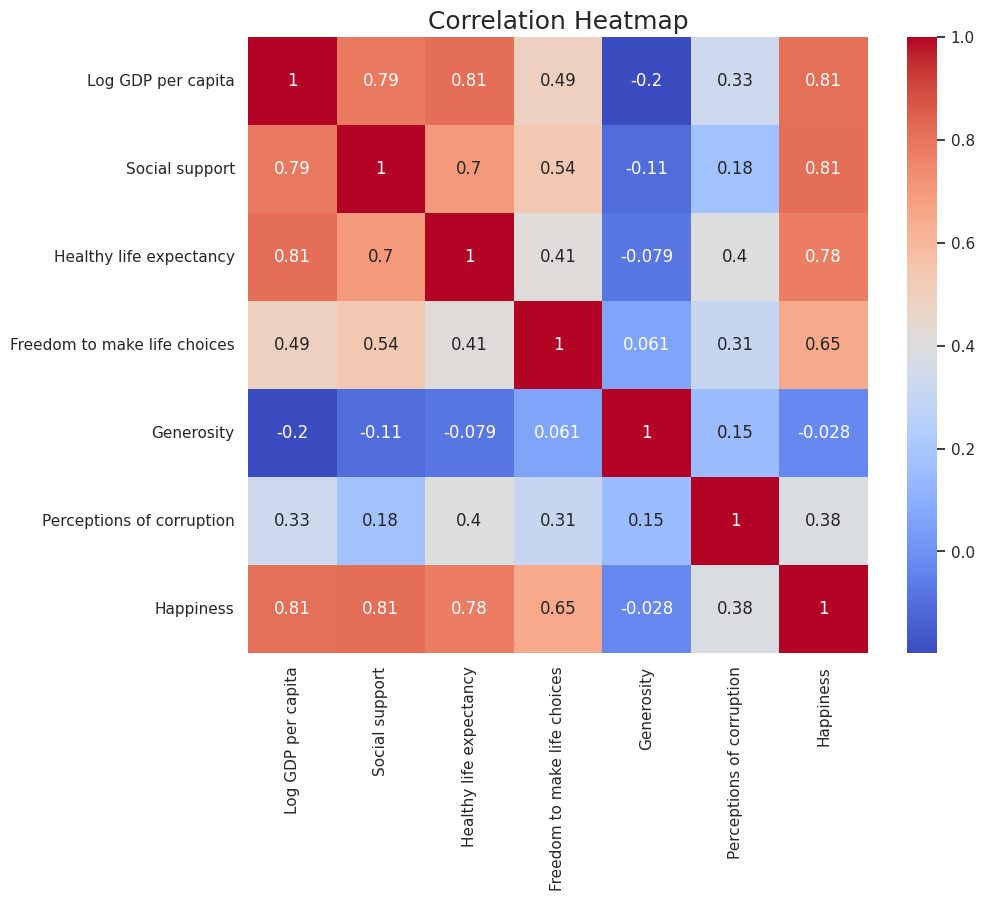

In [ ]:
###################################
####### Correlation Heatmap #######
###################################

factors = [
    'Log GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]
country_factors_mean = (df_2019.groupby('Country')[factors + ['Happiness']].mean())

corr = country_factors_mean[factors + ['Happiness']].corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap', fontsize=18)
plt.show()

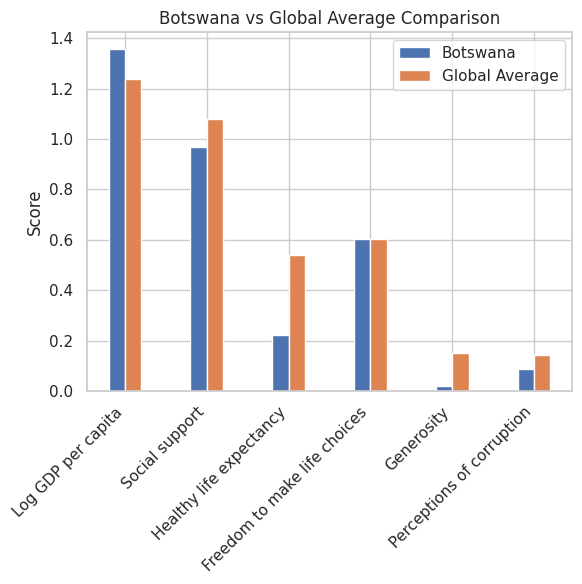

In [ ]:
########################################################
####### Afghanistan vs Global Average Comparison #######
########################################################

country_df = df_2019[df_2019['Country'] == 'Afghanistan'] # also I did for Botswana

features = [
    'Log GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

global_mean = df_2019[features].mean()
country_mean = country_df[features].mean()


compare_df = pd.DataFrame({
    'Feature': features,
    'Country': country_mean.values,
    'Global Average': global_mean.values
})

x = np.arange(len(features))
width = 0.2

plt.figure(figsize=(6,6))

plt.bar(x - width/2, compare_df['Country'], width, label='Afghanistan')
plt.bar(x + width/2, compare_df['Global Average'], width, label='Global Average')

plt.title(f'Afghanistan vs Global Average Comparison')
plt.ylabel('Score')
plt.xticks(x, features, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()